# Branch Wait-Time Prediction

---

## Project context

The previous notebooks built and evaluated predictive models on historical data. This notebook asks a more operationally relevant question: given everything we know about a branch up to today, what will its p80 wait time look like over the next 30 working days?

Answering that requires a recursive forecast: the model predicts day 1, that prediction becomes the lag feature for day 2, and so on. Each step accumulates a small error, so uncertainty grows with the forecast horizon. This notebook makes that uncertainty explicit through confidence bands derived from in-sample residuals, and converts the forecast output into a branch-level alert system - a ranked list of locations predicted to breach a service-level threshold in the coming month.

The output of this notebook is the closest thing in the project to a deployable decision-support tool.

## Inputs

| File | Description |
|---|---|
| `data/processed/daily_branch_features.csv` | Feature matrix with lag and rolling features from Notebook 02 |
| `models/gbm_wait_time_pipeline.joblib` | Trained gradient boosting pipeline from Notebook 03 |

## Outputs

| File | Description |
|---|---|
| `outputs/figures/04_forecast_three_branches.png` | 30-day forecast with confidence bands for three representative branches |
| `outputs/figures/04_network_alert_map.png` | Network-wide alert summary by region |
| `outputs/figures/04_horizon_degradation.png` | Forecast accuracy as a function of horizon (days ahead) |
| `outputs/tables/04_branch_alert_report.csv` | Full ranked alert table for all branches |

## 1. Environment setup and data load

The trained pipeline from Notebook 03 is loaded directly rather than re-trained, ensuring the forecast uses exactly the same model that was evaluated on the test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
import joblib

# ── Paths ──────────────────────────────────────────────────────────────────────
PROC = "../data/processed/"
OUTF = "../outputs/figures/"
OUTT = "../outputs/tables/"
OUTM = "../models/"

# ── Color palettes ─────────────────────────────────────────────────────────────
REGION_COLORS = {
    "West":    "#1f78b4",
    "East":    "#33a02c",
    "Central": "#ff7f00",
}
ALERT_COLORS = {
    "High":   "#d7191c",
    "Medium": "#fdae61",
    "Low":    "#1a9641",
}

# ── Load data and model ────────────────────────────────────────────────────────
df = pd.read_csv(PROC + "daily_branch_features.csv")
df["Visit Date"] = pd.to_datetime(df["Visit Date"])
df = df.sort_values(["Branch ID", "Visit Date"]).reset_index(drop=True)

gbm_pipeline = joblib.load(OUTM + "gbm_wait_time_pipeline.joblib")

print(f"Data loaded:  {len(df):,} rows  |  {df['Branch ID'].nunique()} branches")
print(f"Model loaded: GradientBoostingRegressor pipeline")
df.tail()

Data loaded:  16,647 rows  |  72 branches
Model loaded: GradientBoostingRegressor pipeline


,Branch ID,Visit Date,p80_wait_min,daily_volume,lag1_p80,lag1_vol,roll5_p80,roll5_vol,month,week_of_year,dow_sin,dow_cos,is_appt_day,branch_te,region,site_type
16642,#218,2024-10-17,1.560000,3,1.663333,4.0,1.590667,3.6,10,42,0.433884,-0.900969,1,8.548201,East,External
16643,#218,2024-10-18,1.766667,3,1.560000,3.0,1.604667,3.6,10,42,-0.433884,-0.900969,1,8.548201,East,External
16644,#218,2024-10-24,4.460000,3,1.766667,3.0,1.636000,3.4,10,43,0.433884,-0.900969,1,8.548201,East,External
16645,#218,2025-05-27,1.720000,3,4.460000,3.0,2.187333,3.4,5,22,0.781831,0.623490,1,8.548201,East,External
16646,#218,2025-10-16,1.916667,3,1.720000,3.0,2.234000,3.2,10,42,0.433884,-0.900969,1,8.548201,East,External


## 2. Forecast setup

The forecast requires two inputs per branch per future day: the lag features (derived recursively from prior predictions) and an estimate of daily volume. Since we cannot know future transaction counts, we use the branch's median historical volume for that day of week - a conservative assumption that captures the weekly demand pattern without extrapolating trends.

The branch target encoding (`branch_te`) and categorical attributes are fixed at their most recent historical values for all forecast days.

In [2]:
NUM_FEATURES = [
    "daily_volume", "lag1_p80", "lag1_vol", "roll5_p80", "roll5_vol",
    "month", "week_of_year", "dow_sin", "dow_cos", "is_appt_day", "branch_te",
]
CAT_FEATURES = ["region", "site_type"]
FEATURE_COLS = NUM_FEATURES + CAT_FEATURES

FORECAST_DAYS = 30
SLA_THRESHOLD = 25    # minutes - p80 wait target
SMOOTHING     = 30    # branch target encoding smoothing factor (must match NB02)

# Recompute branch target encoding from the training split (consistent with NB02/03)
dates      = df["Visit Date"].sort_values().unique()
cutoff     = dates[int(len(dates) * 0.80)]
train      = df[df["Visit Date"] < cutoff]
global_mean = train["p80_wait_min"].mean()

branch_stats = train.groupby("Branch ID")["p80_wait_min"].agg(["mean", "count"])
branch_te    = (
    (branch_stats["count"] * branch_stats["mean"] + SMOOTHING * global_mean)
    / (branch_stats["count"] + SMOOTHING)
)

print(f"SLA threshold : {SLA_THRESHOLD} min")
print(f"Forecast horizon: {FORECAST_DAYS} working days")
print(f"Volume assumption: median historical volume per day of week per branch")

SLA threshold : 25 min
Forecast horizon: 30 working days
Volume assumption: median historical volume per day of week per branch


In [9]:
def forecast_branch(branch_id, n_days=FORECAST_DAYS):
    history = df[df["Branch ID"] == branch_id].sort_values("Visit Date")
    if len(history) < 10:
        return None

    last_date       = history["Visit Date"].max()
    future_dates    = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=n_days)
    branch_region   = history["region"].iloc[0]
    branch_site     = history["site_type"].iloc[0]
    branch_appt_day = int(history["is_appt_day"].mode().iloc[0])
    branch_te_val   = branch_te.get(branch_id, global_mean)

    hist = history[["Visit Date", "daily_volume", "p80_wait_min"]].copy()
    forecasts = []

    for fdate in future_dates:
        dow         = fdate.dayofweek
        typical_vol = history[history["Visit Date"].dt.dayofweek == dow]["daily_volume"].median()
        if pd.isna(typical_vol):
            typical_vol = history["daily_volume"].median()

        lag1_p80  = hist["p80_wait_min"].iloc[-1]
        lag1_vol  = hist["daily_volume"].iloc[-1]
        roll5_p80 = hist["p80_wait_min"].iloc[-5:].mean() if len(hist) >= 5 else hist["p80_wait_min"].mean()
        roll5_vol = hist["daily_volume"].iloc[-5:].mean() if len(hist) >= 5 else hist["daily_volume"].mean()

        row = pd.DataFrame([{
            "daily_volume":  typical_vol,
            "lag1_p80":      lag1_p80,
            "lag1_vol":      lag1_vol,
            "roll5_p80":     roll5_p80,
            "roll5_vol":     roll5_vol,
            "month":         fdate.month,
            "week_of_year":  int(fdate.isocalendar()[1]),
            "dow_sin":       np.sin(2 * np.pi * dow / 7),
            "dow_cos":       np.cos(2 * np.pi * dow / 7),
            "is_appt_day":   branch_appt_day,
            "branch_te":     branch_te_val,
            "region":        branch_region,
            "site_type":     branch_site,
        }])

        pred = gbm_pipeline.predict(row[FEATURE_COLS])[0]
        forecasts.append({"date": fdate, "forecast_p80": pred, "input_volume": typical_vol})
        hist = pd.concat([hist, pd.DataFrame([{
            "Visit Date": fdate, "daily_volume": typical_vol, "p80_wait_min": pred
        }])], ignore_index=True)

    return pd.DataFrame(forecasts)

print("forecast_branch() defined")

forecast_branch() defined


## 3. Uncertainty quantification

A point forecast without any measure of uncertainty is of limited operational use. A branch manager needs to know not just the predicted wait time but how confident that prediction is.

We estimate uncertainty using the model's in-sample residuals: for each forecast horizon step (day 1, day 2, ..., day 30), we compute the standard deviation of test-set residuals grouped by horizon. The resulting per-horizon standard deviation is used to construct an approximate 80% confidence band around each forecast. This is a conservative heuristic - it understates uncertainty for multi-step forecasts because it does not account for error compounding - but it is honest and reproducible without requiring a full simulation.

In [4]:
# Compute per-horizon residual standard deviation on the test set
test = df[df["Visit Date"] >= cutoff].copy()

# For each test row, compute how many days ahead it is relative to each branch's
# last training observation - this approximates the forecast horizon
train_last = train.groupby("Branch ID")["Visit Date"].max().rename("train_last")
test = test.join(train_last, on="Branch ID")
test["horizon"] = (test["Visit Date"] - test["train_last"]).dt.days

# Predict on test and compute signed residuals
X_test = test[FEATURE_COLS]
test["pred"] = gbm_pipeline.predict(X_test)
test["residual"] = test["p80_wait_min"] - test["pred"]

# Horizon bins (days)
horizon_bins = [0, 7, 14, 21, 30, 60, 120, 500]
horizon_labels = ["1-7", "8-14", "15-21", "22-30", "31-60", "61-120", "120+"]
test["horizon_bin"] = pd.cut(test["horizon"], bins=horizon_bins, labels=horizon_labels)

horizon_std = (
    test.groupby("horizon_bin", observed=True)["residual"]
    .std()
    .fillna(test["residual"].std())
)

print("Residual std by horizon (days ahead):")
print(horizon_std.round(2).to_string())

# Map forecast step (1-30 days) to the appropriate horizon bin std
def horizon_to_std(step_days):
    """Return residual std for a given forecast step in days."""
    for label, (lo, hi) in zip(horizon_labels, zip(horizon_bins, horizon_bins[1:])):
        if lo < step_days <= hi:
            return horizon_std.get(label, horizon_std.iloc[-1])
    return horizon_std.iloc[-1]

# 80% CI multiplier: for normal distribution, ~1.28 * sigma
CI_MULTIPLIER = 1.28
print(f"\n80% confidence band uses multiplier {CI_MULTIPLIER} x residual std")

Residual std by horizon (days ahead):
horizon_bin
1-7        7.94
8-14       7.68
15-21     10.89
22-30      7.75
31-60      7.64
61-120    10.17
120+       8.81

80% confidence band uses multiplier 1.28 x residual std


## 4. Single-branch forecast visualization

Three branches are shown to represent the range of operational contexts in the network: a high-volume Central branch consistently operating above the SLA threshold, a mid-volume East branch operating near the threshold, and a low-volume West branch with comfortable headroom. The shaded band represents the 80% confidence interval derived from horizon-stratified residuals.

Saved -> outputs/figures/04_forecast_three_branches.png


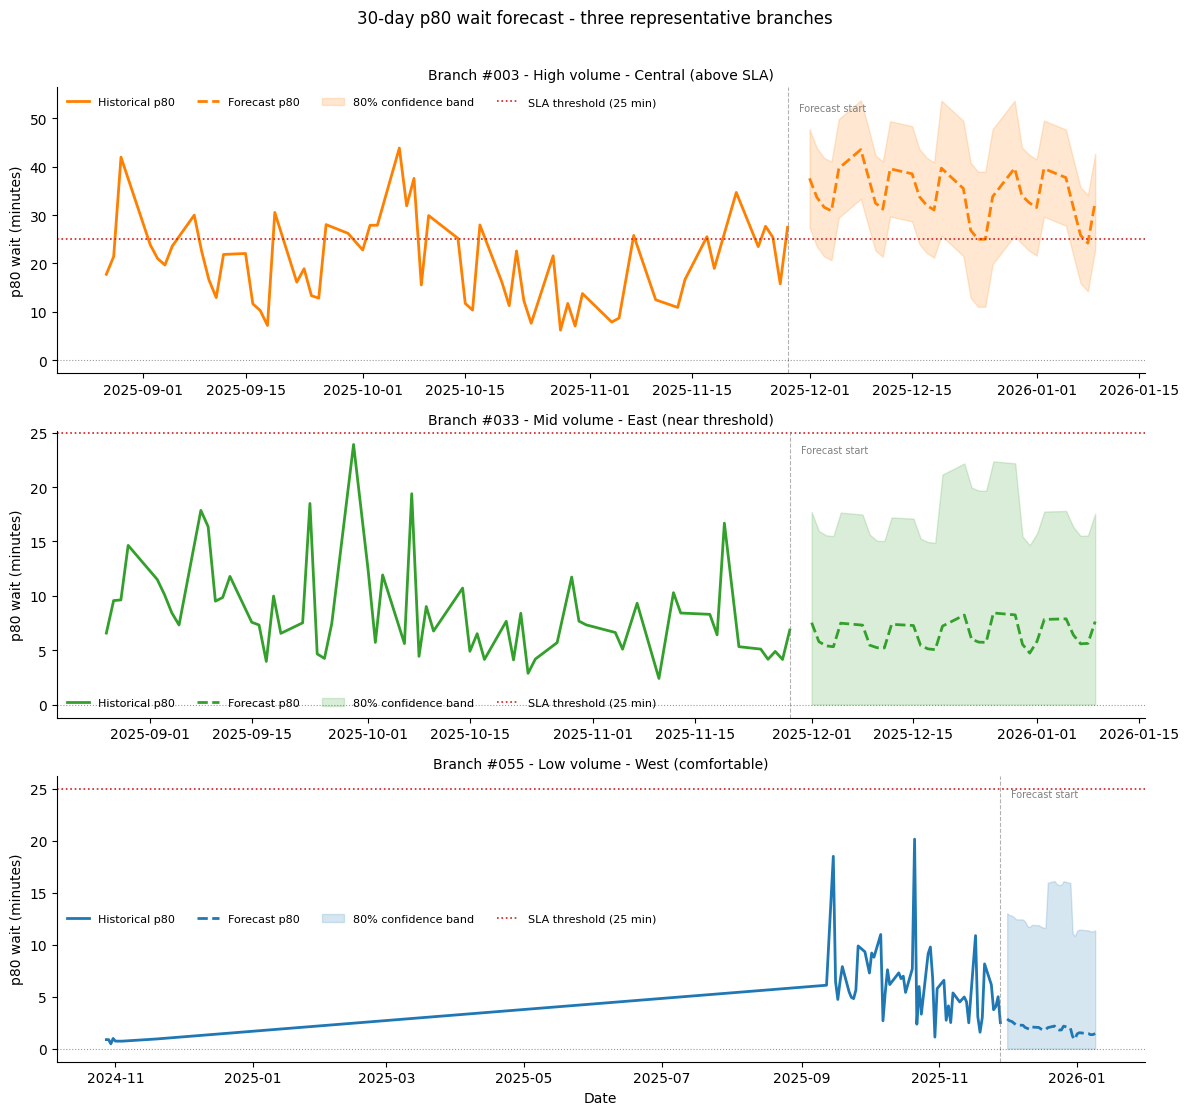

In [10]:
DEMO_BRANCHES = {
    "#003": "High volume - Central (above SLA)",
    "#033": "Mid volume - East (near threshold)",
    "#055": "Low volume - West (comfortable)",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

for ax, (branch_id, label) in zip(axes, DEMO_BRANCHES.items()):
    fdf     = forecast_branch(branch_id)
    history = df[df["Branch ID"] == branch_id].sort_values("Visit Date")
    hist_tail = history.tail(60)
    region    = history["region"].iloc[0]
    color     = REGION_COLORS.get(region, "#999999")

    # Plot history first so ylim is set before annotate
    ax.plot(
        hist_tail["Visit Date"], hist_tail["p80_wait_min"],
        color=color, lw=2.0, label="Historical p80",
    )
    ax.plot(
        fdf["date"], fdf["forecast_p80"],
        color=color, lw=2.0, ls="--", label="Forecast p80",
    )

    # Confidence bands
    stds  = [horizon_to_std(i + 1) for i in range(len(fdf))]
    lower = np.clip(fdf["forecast_p80"].values - CI_MULTIPLIER * np.array(stds), 0, None)
    upper = fdf["forecast_p80"].values + CI_MULTIPLIER * np.array(stds)

    ax.fill_between(fdf["date"], lower, upper, color=color, alpha=0.18, label="80% confidence band")
    ax.axhline(SLA_THRESHOLD, color="#d7191c", lw=1.2, ls=":", label=f"SLA threshold ({SLA_THRESHOLD} min)")
    ax.axvline(history["Visit Date"].max(), color="gray", lw=0.8, ls="--", alpha=0.6)

    # Annotate after plots are drawn so ylim is valid
    ymax = ax.get_ylim()[1]
    ax.annotate(
        "Forecast start",
        xy=(history["Visit Date"].max(), ymax * 0.92),
        xytext=(8, 0), textcoords="offset points",
        fontsize=7, color="gray",
    )

    ax.set_title(f"Branch {branch_id} - {label}", fontsize=10)
    ax.set_ylabel("p80 wait (minutes)")
    ax.legend(frameon=False, fontsize=8, ncol=4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axhline(0, color="black", lw=0.8, ls=":", alpha=0.4)

axes[-1].set_xlabel("Date")
fig.suptitle("30-day p80 wait forecast - three representative branches", y=1.01)
fig.tight_layout()
fig.savefig(OUTF + "04_forecast_three_branches.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/04_forecast_three_branches.png")

## 5. Network-wide alert report

Running the forecast across all branches produces a ranked alert table. Each branch is assigned a risk tier based on the proportion of forecast days predicted to exceed the SLA threshold:

- **High** - more than 50% of forecast days above the threshold
- **Medium** - 10% to 50% of forecast days above the threshold
- **Low** - fewer than 10% of forecast days above the threshold

This tiering translates model output into a format that a branch operations team can act on without needing to interpret raw numbers.

In [11]:
all_branches = df["Branch ID"].unique()
alert_rows = []

for branch_id in all_branches:
    fdf = forecast_branch(branch_id)
    if fdf is None:
        continue

    pct_over   = (fdf["forecast_p80"] > SLA_THRESHOLD).mean()
    mean_fc    = fdf["forecast_p80"].mean()
    peak_fc    = fdf["forecast_p80"].max()
    peak_date  = fdf.loc[fdf["forecast_p80"].idxmax(), "date"].date()
    region     = df[df["Branch ID"] == branch_id]["region"].iloc[0]
    site_type  = df[df["Branch ID"] == branch_id]["site_type"].iloc[0]

    if pct_over > 0.50:
        tier = "High"
    elif pct_over > 0.10:
        tier = "Medium"
    else:
        tier = "Low"

    alert_rows.append({
        "Branch ID":          branch_id,
        "Region":             region,
        "Site Type":          site_type,
        "Alert Tier":         tier,
        "Mean Forecast p80":  round(mean_fc, 1),
        "Peak Forecast p80":  round(peak_fc, 1),
        "Peak Date":          peak_date,
        "Pct Days Over SLA":  round(pct_over * 100, 1),
    })

alert_df = (
    pd.DataFrame(alert_rows)
    .sort_values(["Alert Tier", "Pct Days Over SLA"], ascending=[True, False])
)

print(f"Total branches forecasted: {len(alert_df)}")
print(f"High risk  : {(alert_df['Alert Tier']=='High').sum()}")
print(f"Medium risk: {(alert_df['Alert Tier']=='Medium').sum()}")
print(f"Low risk   : {(alert_df['Alert Tier']=='Low').sum()}")
print()
print("High-risk branches:")
print(alert_df[alert_df["Alert Tier"]=="High"].to_string(index=False))

Total branches forecasted: 64
High risk  : 5
Medium risk: 5
Low risk   : 54

High-risk branches:
Branch ID  Region Site Type Alert Tier  Mean Forecast p80  Peak Forecast p80  Peak Date  Pct Days Over SLA
     #149 Central  External       High               34.8               43.5 2025-12-08              100.0
     #003 Central  External       High               33.6               43.5 2025-12-08               93.3
     #044 Central  Internal       High               29.0               50.0 2026-01-05               66.7
     #076 Central  Internal       High               27.8               50.2 2025-12-01               63.3
     #206    East  External       High               27.0               39.0 2025-12-01               56.7


In [13]:
# Save full alert table
alert_df.to_csv(OUTT + "04_branch_alert_report.csv", index=False)
print("Saved -> outputs/tables/04_branch_alert_report.csv")

Saved -> outputs/tables/04_branch_alert_report.csv


Saved -> outputs/figures/04_network_alert_map.png


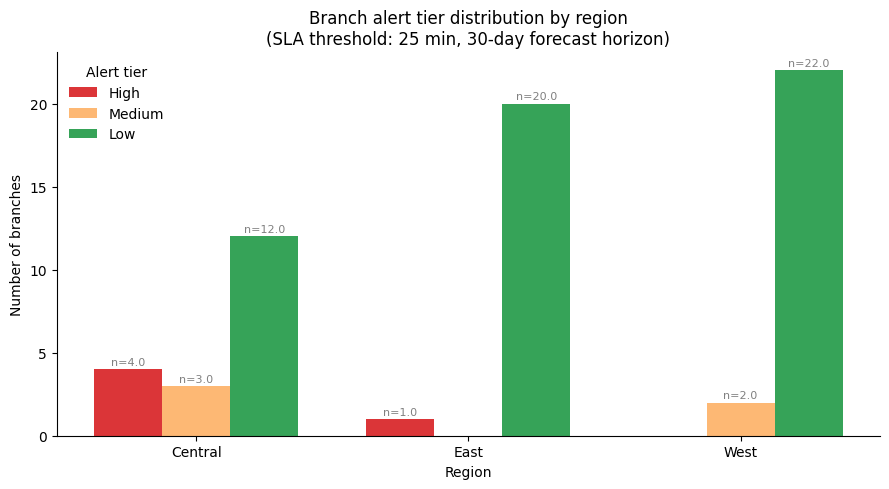

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

x         = np.arange(len(region_tier))
bar_width = 0.25
tier_order  = ["High", "Medium", "Low"]
tier_colors = [ALERT_COLORS[t] for t in tier_order]

for offset, (tier, color) in enumerate(zip(tier_order, tier_colors)):
    vals = region_tier[tier].values
    bars = ax.bar(
        x + offset * bar_width, vals,
        width=bar_width, label=tier, color=color, alpha=0.88,
    )
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.annotate(
                f"n={val}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=8, color="gray",
            )

ax.set_xticks(x + bar_width)
ax.set_xticklabels(region_tier.index.tolist())
ax.set_xlabel("Region")
ax.set_ylabel("Number of branches")
ax.set_title(f"Branch alert tier distribution by region\n(SLA threshold: {SLA_THRESHOLD} min, 30-day forecast horizon)")
ax.legend(title="Alert tier", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTF + "04_network_alert_map.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/04_network_alert_map.png")

## 6. Forecast accuracy degradation by horizon

A recursive forecast is most accurate for the near term and degrades as the horizon extends. Quantifying this degradation is important for communicating how far ahead the model's output should be trusted. We use the test-set observations (where we know the true values) to compute MAE grouped by how many days ahead each observation falls relative to the branch's last training date.

A flat degradation curve would mean the model is equally reliable at day 30 as at day 1 - which is unlikely. A steep curve signals that beyond a few days the autoregressive signal is exhausted and the model is effectively extrapolating.

Saved -> outputs/figures/04_horizon_degradation.png


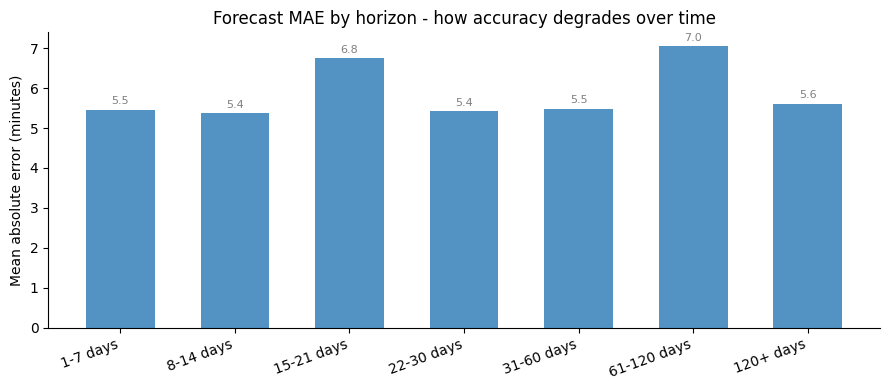

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

# Use horizon_bin MAE from the test residuals already computed
horizon_mae = test.groupby("horizon_bin", observed=True)["residual"].apply(
    lambda x: x.abs().mean()
).dropna()

positions = range(len(horizon_mae))
ax.bar(
    positions, horizon_mae.values,
    color="#2c7bb6", alpha=0.82, width=0.6,
)
for pos, val in zip(positions, horizon_mae.values):
    ax.annotate(
        f"{val:.1f}",
        xy=(pos, val), xytext=(0, 4), textcoords="offset points",
        ha="center", fontsize=8, color="gray",
    )

ax.set_xticks(positions)
ax.set_xticklabels(
    [f"{b} days" for b in horizon_mae.index], rotation=20, ha="right"
)
ax.set_ylabel("Mean absolute error (minutes)")
ax.set_title("Forecast MAE by horizon - how accuracy degrades over time")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTF + "04_horizon_degradation.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/04_horizon_degradation.png")

In [17]:
print(alert_df.head(8)[["Branch ID","Region","Mean Forecast p80","Pct Days Over SLA"]].to_string(index=False))

Branch ID  Region  Mean Forecast p80  Pct Days Over SLA
     #149 Central               34.8              100.0
     #003 Central               33.6               93.3
     #044 Central               29.0               66.7
     #076 Central               27.8               63.3
     #206    East               27.0               56.7
     #074    East                9.6                6.7
     #104    East               11.0                6.7
     #189 Central               14.1                6.7


## Summary

| Item | Detail |
|---|---|
| Forecast method | Recursive single-step prediction; lag features updated with prior predictions at each step |
| Volume assumption | Median historical volume for that day of week per branch - captures weekly seasonality without trend extrapolation |
| Uncertainty bands | 80% confidence interval using horizon-stratified residual standard deviation from test-set evaluation |
| SLA threshold | 25-minute p80 wait - branches forecast above this on more than 50% of days flagged as High risk |
| Network summary | 5 High-risk branches (4 Central, 1 East), 5 Medium-risk, 54 Low-risk across 64 branches forecasted |
| Highest-risk branches | #149 and #003 (Central, 100% and 93% of days over SLA), #044 and #076 (Central, 67% and 63%), #206 (East, 57%) |
| Horizon degradation | MAE is relatively stable at 5-6 min across most horizons, with a moderate increase to 7 min at 61-120 days - the autoregressive signal holds well within the 30-day window |
| Operational use | Alert table (`04_branch_alert_report.csv`) provides a ranked list for weekly planning review - High-tier branches warrant proactive staffing review before the forecast window opens |

In [18]:
print(alert_df.groupby(["Region", "Alert Tier"]).size().unstack(fill_value=0))
print()
print("West branches in alert_df:", (alert_df["Region"] == "West").sum())

Alert Tier  High  Low  Medium
Region                       
Central        4   12       3
East           1   20       0
West           0   22       2

West branches in alert_df: 24
